<a href="https://colab.research.google.com/github/RyMack05/ML-fundamentals-2026/blob/main/assignment_1_Ryann_Mack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 – ML Fundamentals 2026

##Author: Ryann Mack

###Goal:
Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)

### Overview

In this assignment, I use the UCI Bank Marketing dataset to predict whether a client subscribes to a term deposit (`y ∈ {yes, no}`), based only on information available at the time of contact.

## Order of Data Preparation

1. **Target Identification**  
   Confirm y as the prediction target and define the prediction-time constraint.

2. **Exploratory Data Analysis (EDA)**  
   Analyze dataset structure, class imbalance, and identify suspicious variables. No transformations are applied at this stage.

3. **Stratified Data Splitting**  
   Split the dataset into 60% training, 20% validation, and 20% test sets.   Splitting is performed before any preprocessing to avoid leakage.

4. **Preprocessing (Training-Only Fitting)**  
   Handle missing values, encode categorical variables, and scale numerical features using parameters learned from the training set only.

5. **Feature Selection and Imbalance Handling**  
   Remove invalid or redundant features and address class imbalance using the training set only.

6. **Model Training and Evaluation**  
   Train a Logistic Regression model and evaluate performance using appropriate classification metrics.

## Target

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
url = "https://raw.githubusercontent.com/RyMack05/ML-fundamentals-2026/refs/heads/main/bank-additional.csv"

df = pd.read_csv(url, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 1. Identifying the Prediction Target

We predict `y` because it directly represents whether the client subscribed to a term deposit after being contacted.

Two columns that might *look* like targets but are not:
- `duration`: looks like it predicts success, but it is only known after the call (leakage).
- `campaign`: number of calls is not the “outcome”; it’s part of the process/effort, not the success label.

In [ ]:
# Check the unique values of the likely target column
df["y"].value_counts()

,count
y,
no,3668
yes,451


In [ ]:
# Check the percentage of y/n of likely target column
df["y"].value_counts(normalize=True)

,proportion
y,
no,0.890507
yes,0.109493


## 2. Data Loading & Exploration (EDA)

Here we inspect shape, data types, and the distribution of the target.
We also visualize:
- 2 numerical variables
- 2 categorical variables
and we look for **implicit missing values** such as `"unknown"`.

The dataset contains 4119 observations and 21 variables. Each row represents a client contacted during a marketing campaign.

In [4]:
df.shape

(4119, 21)

In [5]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [6]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols, categorical_cols

(Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome', 'y'],
       dtype='object'))

In [7]:
# Explicit missing values
df.isnull().sum().sort_values(ascending=False).head(10)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [8]:
# Implicit missing values ("unknown") - list columns containing it
unknown_cols = []
for col in categorical_cols:
    if "unknown" in df[col].unique():
        unknown_cols.append(col)
unknown_cols

['job', 'marital', 'education', 'default', 'housing', 'loan']

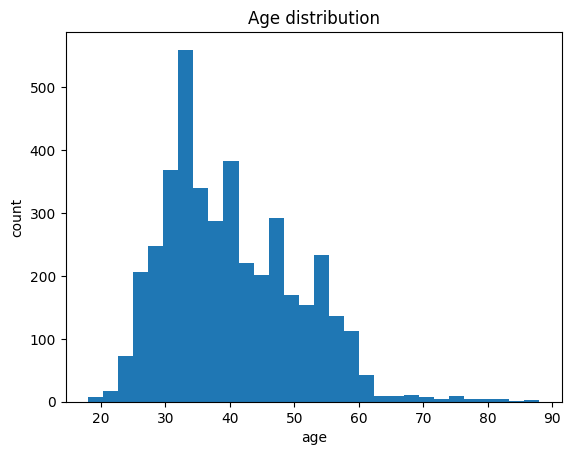

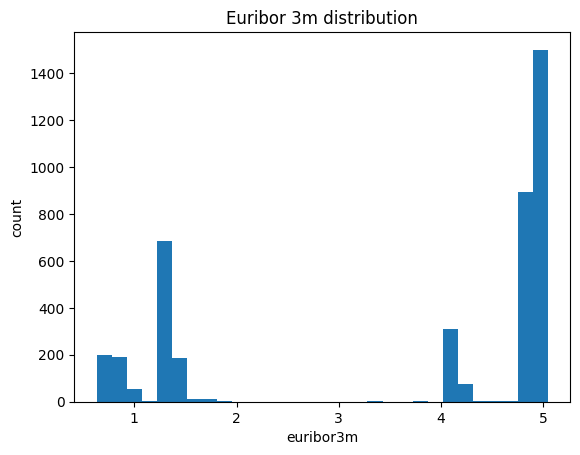

In [9]:
# 2 numerical plots
plt.hist(df["age"], bins=30)
plt.title("Age distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

plt.hist(df["euribor3m"], bins=30)
plt.title("Euribor 3m distribution")
plt.xlabel("euribor3m")
plt.ylabel("count")
plt.show()

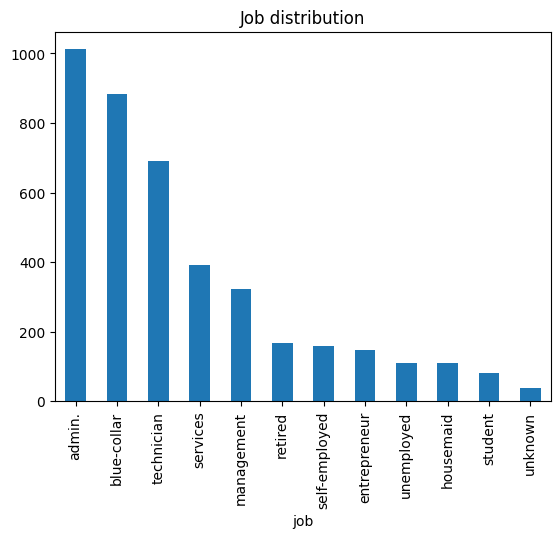

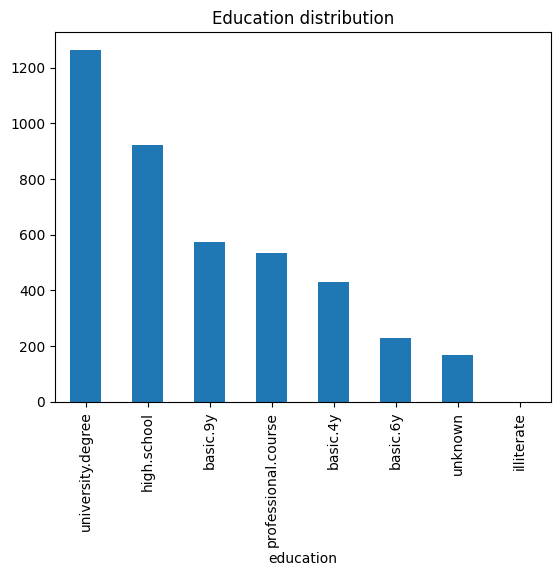

In [10]:
# 2 categorical plots
df["job"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.show()

df["education"].value_counts().plot(kind="bar")
plt.title("Education distribution")
plt.show()

## 3. Variables requiring special consideration (leakage risk)

At prediction time we only know information available **when contacting the client**.

`duration` is a classic leakage variable because call duration is only known after the call ends.
If we keep it, the model will look unrealistically good and evaluation will be misleading.
Therefore we drop `duration` before training.

In [12]:
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Original:", y.value_counts(normalize=True))
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Original: y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64
Train: y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64
Val: y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64
Test: y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


## 4. Missing values (explicit + implicit)

There are no explicit NaNs, but some categorical columns contain `"unknown"`.

We quantify missingness per column and decide a strategy:
- For categorical `"unknown"`: keep it as its own category (it can carry information).
- No imputation needed for NaNs (since there are none).

In [13]:
missing_report = []
for col in unknown_cols:
    n_unknown = (X_train[col] == "unknown").sum()
    pct_unknown = n_unknown / len(X_train)
    missing_report.append((col, n_unknown, pct_unknown))

missing_df = pd.DataFrame(missing_report, columns=["column", "n_unknown_in_train", "pct_unknown_in_train"])
missing_df.sort_values("pct_unknown_in_train", ascending=False)

,column,n_unknown_in_train,pct_unknown_in_train
3,default,492,0.199110
2,education,104,0.042088
4,housing,55,0.022258
5,loan,55,0.022258
0,job,20,0.008094
1,marital,7,0.002833


## 5. Feature selection (including leakage removal)

We remove features that should not be used:
- `duration` (leakage)

We also check for:
- very low-variance features (if any)
- highly correlated numerical features (optional/simple check)

In [14]:
leakage_features = ["duration"]  # main leakage feature
X_train = X_train.drop(columns=leakage_features)
X_val = X_val.drop(columns=leakage_features)
X_test = X_test.drop(columns=leakage_features)

## 6. Encoding categorical variables

Logistic Regression needs numbers, so we encode categories.

- Nominal (no order): one-hot encoding
- Ordinal (has meaningful order): ordinal encoding IF we can justify a real order

In this dataset:
- `education` can be treated as ordinal only if we define an order and justify it.
- `month` and `day_of_week` are NOT ordinal (they are cyclical labels), so we treat them as nominal (one-hot).

In [15]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

categorical_nominal = list(categorical_cols)  # keep simple: one-hot all categorical
categorical_nominal

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [16]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

ohe.fit(X_train[categorical_nominal])

X_train_ohe = ohe.transform(X_train[categorical_nominal])
X_val_ohe = ohe.transform(X_val[categorical_nominal])
X_test_ohe = ohe.transform(X_test[categorical_nominal])

ohe_cols = ohe.get_feature_names_out(categorical_nominal)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

## 7. Feature scaling (numerical)

Logistic Regression is sensitive to feature magnitudes.
We standardize numerical columns (z-score) so gradients behave nicely and coefficients become comparable.

IMPORTANT: Fit scaler on training only.

In [17]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

X_train_num = pd.DataFrame(scaler.transform(X_train[numerical_cols]), columns=numerical_cols, index=X_train.index)
X_val_num = pd.DataFrame(scaler.transform(X_val[numerical_cols]), columns=numerical_cols, index=X_val.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numerical_cols]), columns=numerical_cols, index=X_test.index)

In [18]:
X_train_final = pd.concat([X_train_num, X_train_ohe], axis=1)
X_val_final = pd.concat([X_val_num, X_val_ohe], axis=1)
X_test_final = pd.concat([X_test_num, X_test_ohe], axis=1)

X_train_final.shape, X_val_final.shape, X_test_final.shape

((2471, 62), (824, 62), (824, 62))

## 8. Addressing class imbalance (training only)

The dataset is imbalanced (~11% positive).
Accuracy can look high even for a dumb model, so we also report precision/recall.

Resampling must be applied to training only.
If we resample before splitting, synthetic/duplicated examples can leak into validation/test and inflate results.

In [19]:
train_df = X_train_final.copy()
train_df["y"] = y_train.values

majority = train_df[train_df["y"] == "no"]
minority = train_df[train_df["y"] == "yes"]

minority_upsampled = minority.sample(n=len(majority), replace=True, random_state=42)

train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

y_train_bal = train_balanced["y"]
X_train_bal = train_balanced.drop(columns=["y"])

y_train_bal.value_counts()

,count
y,
no,2200
yes,2200


## 9. Zero Rule baseline

Zero-rule predicts the most frequent class every time.
This is the simplest “do nothing” baseline.

In [20]:
most_common = y_train.value_counts().idxmax()
y_val_pred_zero = np.array([most_common] * len(y_val))

zero_acc = accuracy_score(y_val, y_val_pred_zero)
zero_acc

0.8907766990291263

## 10. Logistic Regression sanity check

Goal: verify the pipeline behaves sensibly (not maximize performance).

We train on the processed training set and evaluate on validation.
We report accuracy, precision, recall and compare against zero-rule.

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_bal, y_train_bal)

y_val_pred = lr.predict(X_val_final)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec = recall_score(y_val, y_val_pred, pos_label="yes")

print("Zero-rule accuracy:", zero_acc)
print("LR accuracy:", acc)
print("LR precision:", prec)
print("LR recall:", rec)

Zero-rule accuracy: 0.8907766990291263
LR accuracy: 0.8264563106796117
LR precision: 0.3374233128834356
LR recall: 0.6111111111111112


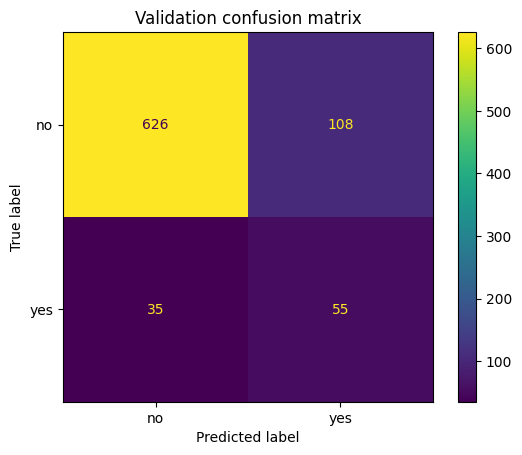

In [22]:
cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot()
plt.title("Validation confusion matrix")
plt.show()